In [25]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np
import tqdm
import sys
import pickle
import os

# sys.path.append('/Users/nmehlman/Library/Mobile Documents/com~apple~CloudDocs/Desktop/CSCI 699/Project/poison-perf')
cwd = os.getcwd()
root = os.path.dirname(cwd)
sys.path.append(root)

from utils.algorithms import RGD, PerfGD
from utils.experiment_setup import setup_1d_non_linear_experiment, setup_binary_classification, setup_non_convex_nd
from poisoning.oracle import oracle_poison_function, RGD_update_estimator, PerfGD_update_estimator, classification_sampling_estimator, gaussian_sampling_estimator
from poisoning.white_box import white_box_poison_function
from poisoning.black_box import black_box_poison_naive, black_box_poison_cluster, black_box_poison_orthogonal
from utils.plotting import plot_results_1d, plot_results_2d

# 10-Dimensional Non-Convex / RGD

In [26]:
# Hyperparameters
n = 500
eta = 0.04
max_iter = 150
normalize_grad = True
delta = 1.0
epsilon = 0.5
alpha_vals = np.linspace(0.0, 1.0, 10)
poison_step_size = 0.1
norm = 'linf'
n_trials_per_eps = 10
seed = 1216

In [27]:
# Clean training
losses_clean, theta_clean = [], []
for alpha in tqdm.tqdm(alpha_vals):
    
    mu, sigma, D_theta, loss, theta_0, grad2_est, f_hat = setup_non_convex_nd(alpha=alpha, perfGD=True, seed=seed)
    
    theta_clean_avg = []
    loss_clean_avg = []
    for trial in range(n_trials_per_eps):
        _theta_clean, all_theta_clean, all_losses_clean = PerfGD(
                f_hat=f_hat,
                grad2_est=grad2_est,
                D_theta=D_theta,
                loss=loss,
                theta_0=theta_0.clone(),
                n=n,
                eta=eta,
                max_iter=max_iter,
                return_losses=True,
                normalize_grad=normalize_grad
        )
        
        theta_clean_avg.append(_theta_clean)
        loss_clean_avg.append(all_losses_clean[-1])
        
    theta_clean.append(np.mean(theta_clean_avg))
    losses_clean.append(np.mean(loss_clean_avg))
    
theta_clean = np.array(theta_clean)
losses_clean = np.array(losses_clean)

100%|██████████| 10/10 [00:23<00:00,  2.38s/it]


## Black Box Attack

In [28]:
losses_poisoned, theta_poisoned = [], []

for alpha in tqdm.tqdm(alpha_vals):
    
    mu, sigma, D_theta, loss, theta_0, grad2_est, f_hat = setup_non_convex_nd(alpha=alpha, perfGD=True, seed=seed)
    
    losses_poisoned_trial = []
    theta_poisoned_trial = []
    for trial in range(n_trials_per_eps):
    
        _theta_poisoned, _, all_losses_poisoned = RGD(
                D_theta=D_theta,
                loss=loss,
                theta_0=theta_0.clone(),
                n=n,
                eta=eta,
                max_iter=max_iter,
                poison_function=black_box_poison_orthogonal,
                epsilon=epsilon,
                delta=delta,
                normalize_grad=normalize_grad,
                return_losses=True,
    )

        losses_poisoned_trial.append(all_losses_poisoned[-1])
        theta_poisoned_trial.append(_theta_poisoned)
        
    losses_poisoned.append(np.mean(losses_poisoned_trial))
    theta_poisoned.append(np.mean(theta_poisoned_trial, 0))    
    
# Save results
loss_diff = np.array(losses_poisoned) - losses_clean
theta_diff = np.array(theta_poisoned) - theta_clean

results = {
    "loss_diff": loss_diff,
    "theta_diff": theta_diff,
    "alpha_vals": alpha_vals,
}

pickle.dump(results, open(f'../exports/alpha_sweep/non-convex_RGD_black_box_seed{seed}.pkl', 'wb'))

100%|██████████| 10/10 [00:08<00:00,  1.20it/s]


## White Box Attack

In [29]:
losses_poisoned, theta_poisoned = [], []

for alpha in tqdm.tqdm(alpha_vals):
    
    mu, sigma, D_theta, loss, theta_0, grad2_est, f_hat = setup_non_convex_nd(alpha=alpha, perfGD=True, seed=seed)
    
    losses_poisoned_trial = []
    theta_poisoned_trial = []
    for trial in range(n_trials_per_eps):
    
        _theta_poisoned, _, all_losses_poisoned = RGD(
                D_theta=D_theta,
                loss=loss,
                theta_0=theta_0.clone(),
                n=n,
                eta=eta,
                max_iter=max_iter,
                poison_function=white_box_poison_function,
                theta_update_estimator=RGD_update_estimator,
                poison_steps=int(float(delta)//poison_step_size) + 1,
                poison_step_size=poison_step_size,
                epsilon=epsilon,
                delta=delta,
                normalize_grad=normalize_grad,
                return_losses=True,
    )

        losses_poisoned_trial.append(all_losses_poisoned[-1])
        theta_poisoned_trial.append(_theta_poisoned)
        
    losses_poisoned.append(np.mean(losses_poisoned_trial))
    theta_poisoned.append(np.mean(theta_poisoned_trial, 0))    
    
# Save results
loss_diff = np.array(losses_poisoned) - losses_clean
theta_diff = np.array(theta_poisoned) - theta_clean

results = {
    "loss_diff": loss_diff,
    "theta_diff": theta_diff,
    "alpha_vals": alpha_vals,
}

pickle.dump(results, open(f'../exports/alpha_sweep/non-convex_RGD_white_box_seed{seed}.pkl', 'wb'))

100%|██████████| 10/10 [02:38<00:00, 15.80s/it]


## Oracle Attack

In [30]:
losses_poisoned, theta_poisoned = [], []

for alpha in tqdm.tqdm(alpha_vals):
    
    mu, sigma, D_theta, loss, theta_0, grad2_est, f_hat = setup_non_convex_nd(alpha=alpha, perfGD=True, seed=seed)
    
    losses_poisoned_trial = []
    theta_poisoned_trial = []
    for trial in range(n_trials_per_eps):
    
        _theta_poisoned, _, all_losses_poisoned = RGD(
                    D_theta=D_theta,
                    loss=loss,
                    theta_0=theta_0.clone(),
                    n=n,
                    eta=eta,
                    max_iter=max_iter,
                    poison_function=oracle_poison_function,
                    theta_update_estimator=RGD_update_estimator,
                    sampling_estimator=gaussian_sampling_estimator,
                    sampling_estimator_kwargs={'mu': mu, 'sigma': sigma},
                    poison_steps=int(float(delta)//poison_step_size) + 1,
                    poison_step_size=poison_step_size,
                    epsilon=epsilon,
                    delta=delta,
                    return_losses=True,
                    norm=norm,
                    normalize_grad=normalize_grad
        )

        losses_poisoned_trial.append(all_losses_poisoned[-1])
        theta_poisoned_trial.append(_theta_poisoned)
        
    losses_poisoned.append(np.mean(losses_poisoned_trial))
    theta_poisoned.append(np.mean(theta_poisoned_trial, 0))    
    
# Save results
loss_diff = np.array(losses_poisoned) - losses_clean
theta_diff = np.array(theta_poisoned) - theta_clean

results = {
    "loss_diff": loss_diff,
    "theta_diff": theta_diff,
    "alpha_vals": alpha_vals,
}

pickle.dump(results, open(f'../exports/alpha_sweep/non-convex_RGD_oracle_seed{seed}.pkl', 'wb'))

100%|██████████| 10/10 [02:45<00:00, 16.58s/it]


## Plots

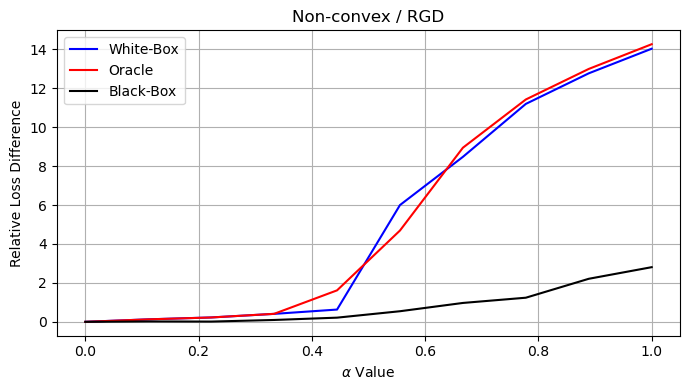

In [31]:
white_box_data = pickle.load(open(f'../exports/alpha_sweep/non-convex_RGD_white_box_seed{seed}.pkl', 'rb'))
oracle_data = pickle.load(open(f'../exports/alpha_sweep/non-convex_RGD_oracle_seed{seed}.pkl', 'rb'))
black_box_data = pickle.load(open(f'../exports/alpha_sweep/non-convex_RGD_black_box_seed{seed}.pkl', 'rb'))

fig, axes = plt.subplots(1, 1, figsize=(7, 4), sharex=True)

# Top: loss difference
axes.plot(white_box_data["alpha_vals"], white_box_data["loss_diff"] - white_box_data["loss_diff"][0], label="White-Box", color="blue")
axes.plot(oracle_data["alpha_vals"], oracle_data["loss_diff"] - oracle_data["loss_diff"][0], label="Oracle", color="red")
axes.plot(black_box_data["alpha_vals"], black_box_data["loss_diff"] - black_box_data["loss_diff"][0], label="Black-Box", color="black")
axes.set_ylabel("Relative Loss Difference")
axes.set_title("Non-convex / RGD")
axes.legend()
axes.grid(True)
axes.set_xlabel(r"$\alpha$ Value")
plt.tight_layout()
plt.show()

# 10-Dimensional Non-Convex / PerfGD

In [32]:
# Clean training
losses_clean, theta_clean = [], []
for alpha in tqdm.tqdm(alpha_vals):
    
    mu, sigma, D_theta, loss, theta_0, grad2_est, f_hat = setup_non_convex_nd(alpha=alpha, perfGD=True, seed=seed)
    
    theta_clean_avg = []
    loss_clean_avg = []
    for trial in range(n_trials_per_eps):
        _theta_clean, _, all_losses_clean = PerfGD(
                    f_hat=f_hat,
                    grad2_est=grad2_est,
                    D_theta=D_theta,
                    loss=loss,
                    theta_0=theta_0.clone(),
                    n=n,
                    eta=eta,
                    max_iter=max_iter,
                    return_losses=True,
                    normalize_grad=normalize_grad,
            )

        theta_clean_avg.append(_theta_clean)
        loss_clean_avg.append(all_losses_clean[-1])
        
    theta_clean.append(np.mean(theta_clean_avg))
    losses_clean.append(np.mean(loss_clean_avg))
    
theta_clean = np.array(theta_clean)
losses_clean = np.array(losses_clean)

100%|██████████| 10/10 [00:24<00:00,  2.50s/it]


## Black Box Attack

In [33]:
losses_poisoned, theta_poisoned = [], []

for alpha in tqdm.tqdm(alpha_vals):
    
    mu, sigma, D_theta, loss, theta_0, grad2_est, f_hat = setup_non_convex_nd(alpha=alpha, perfGD=True, seed=seed)
    
    losses_poisoned_trial = []
    theta_poisoned_trial = []
    for trial in range(n_trials_per_eps):
    
        _theta_poisoned, _, all_losses_poisoned = PerfGD(
                f_hat=f_hat,
                grad2_est=grad2_est,
                D_theta=D_theta,
                loss=loss,
                theta_0=theta_0.clone(),
                n=n,
                eta=eta,
                max_iter=max_iter,
                return_losses=True,
                poison_function=black_box_poison_orthogonal,
                epsilon=epsilon,
                delta=delta,
                normalize_grad=normalize_grad
        )

        losses_poisoned_trial.append(all_losses_poisoned[-1])
        theta_poisoned_trial.append(_theta_poisoned)
        
    losses_poisoned.append(np.mean(losses_poisoned_trial))
    theta_poisoned.append(np.mean(theta_poisoned_trial, 0))    
    
# Save results
loss_diff = np.array(losses_poisoned) - losses_clean
theta_diff = np.array(theta_poisoned) - theta_clean

results = {
    "loss_diff": loss_diff,
    "theta_diff": theta_diff,
    "alpha_vals": alpha_vals,
}

pickle.dump(results, open(f'../exports/alpha_sweep/non-convex_PerfGD_black_box_seed{seed}.pkl', 'wb'))

100%|██████████| 10/10 [00:21<00:00,  2.19s/it]


## White Box Attack

In [34]:
losses_poisoned, theta_poisoned = [], []

for alpha in tqdm.tqdm(alpha_vals):
    
    mu, sigma, D_theta, loss, theta_0, grad2_est, f_hat = setup_non_convex_nd(alpha=alpha, perfGD=True, seed=seed)
    
    losses_poisoned_trial = []
    theta_poisoned_trial = []
    for trial in range(n_trials_per_eps):
    
        _theta_poisoned, _, all_losses_poisoned = PerfGD(
                f_hat=f_hat,
                grad2_est=grad2_est,
                D_theta=D_theta,
                loss=loss,
                theta_0=theta_0.clone(),
                n=n,
                eta=eta,
                max_iter=max_iter,
                return_losses=True,
                poison_function=white_box_poison_function,
                theta_update_estimator=PerfGD_update_estimator,
                poison_steps=int(float(delta)//poison_step_size) + 1,
                poison_step_size=poison_step_size,
                epsilon=epsilon,
                delta=delta,
                normalize_grad=normalize_grad
        )

        losses_poisoned_trial.append(all_losses_poisoned[-1])
        theta_poisoned_trial.append(_theta_poisoned)
        
    losses_poisoned.append(np.mean(losses_poisoned_trial))
    theta_poisoned.append(np.mean(theta_poisoned_trial, 0))    
    
# Save results
loss_diff = np.array(losses_poisoned) - losses_clean
theta_diff = np.array(theta_poisoned) - theta_clean

results = {
    "loss_diff": loss_diff,
    "theta_diff": theta_diff,
    "alpha_vals": alpha_vals,
}

pickle.dump(results, open(f'../exports/alpha_sweep/non-convex_PerfGD_white_box_seed{seed}.pkl', 'wb'))

100%|██████████| 10/10 [09:21<00:00, 56.11s/it]


## Oracle Attack

In [35]:
losses_poisoned, theta_poisoned = [], []

for alpha in tqdm.tqdm(alpha_vals):
    
    mu, sigma, D_theta, loss, theta_0, grad2_est, f_hat = setup_non_convex_nd(alpha=alpha, perfGD=True, seed=seed)
    
    losses_poisoned_trial = []
    theta_poisoned_trial = []
    for trial in range(n_trials_per_eps):
    
        _theta_poisoned, _, all_losses_poisoned = PerfGD(
                f_hat=f_hat,
                grad2_est=grad2_est,
                D_theta=D_theta,
                loss=loss,
                theta_0=theta_0.clone(),
                n=n,
                eta=eta,
                max_iter=max_iter,
                return_losses=True,
                poison_function=oracle_poison_function,
                theta_update_estimator=PerfGD_update_estimator,
                poison_steps=int(float(delta)//poison_step_size) + 1,
                poison_step_size=poison_step_size,
                epsilon=epsilon,
                delta=delta,
                sampling_estimator=gaussian_sampling_estimator,
                sampling_estimator_kwargs={'mu': mu, 'sigma': sigma},
                normalize_grad=normalize_grad
    )

        losses_poisoned_trial.append(all_losses_poisoned[-1])
        theta_poisoned_trial.append(_theta_poisoned)
        
    losses_poisoned.append(np.mean(losses_poisoned_trial))
    theta_poisoned.append(np.mean(theta_poisoned_trial, 0))    
    
# Save results
loss_diff = np.array(losses_poisoned) - losses_clean
theta_diff = np.array(theta_poisoned) - theta_clean

results = {
    "loss_diff": loss_diff,
    "theta_diff": theta_diff,
    "alpha_vals": alpha_vals,
}

pickle.dump(results, open(f'../exports/alpha_sweep/non-convex_PerfGD_oracle_seed{seed}.pkl', 'wb'))

100%|██████████| 10/10 [08:34<00:00, 51.46s/it]


## Plots

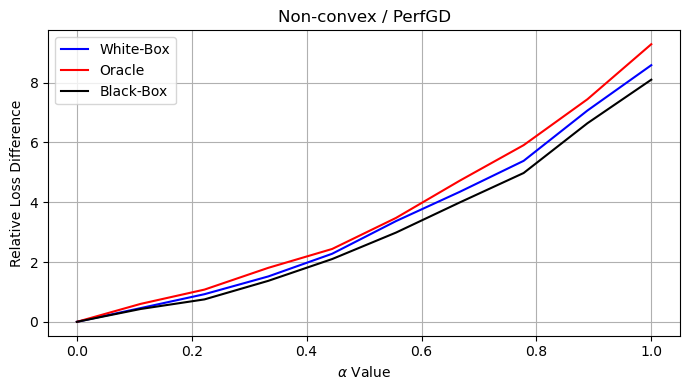

In [36]:
white_box_data = pickle.load(open(f'../exports/alpha_sweep/non-convex_PerfGD_white_box_seed{seed}.pkl', 'rb'))
oracle_data = pickle.load(open(f'../exports/alpha_sweep/non-convex_PerfGD_oracle_seed{seed}.pkl', 'rb'))
black_box_data = pickle.load(open(f'../exports/alpha_sweep/non-convex_PerfGD_black_box_seed{seed}.pkl', 'rb'))

fig, axes = plt.subplots(1, 1, figsize=(7, 4), sharex=True)

# Top: loss difference
axes.plot(white_box_data["alpha_vals"], white_box_data["loss_diff"] - white_box_data["loss_diff"][0], label="White-Box", color="blue")
axes.plot(oracle_data["alpha_vals"], oracle_data["loss_diff"] - oracle_data["loss_diff"][0], label="Oracle", color="red")
axes.plot(black_box_data["alpha_vals"], black_box_data["loss_diff"] - black_box_data["loss_diff"][0], label="Black-Box", color="black")
axes.set_ylabel("Relative Loss Difference")
axes.set_title("Non-convex / PerfGD")
axes.legend()
axes.grid(True)
axes.set_xlabel(r"$\alpha$ Value")
plt.tight_layout()
plt.show()

# Full Plot

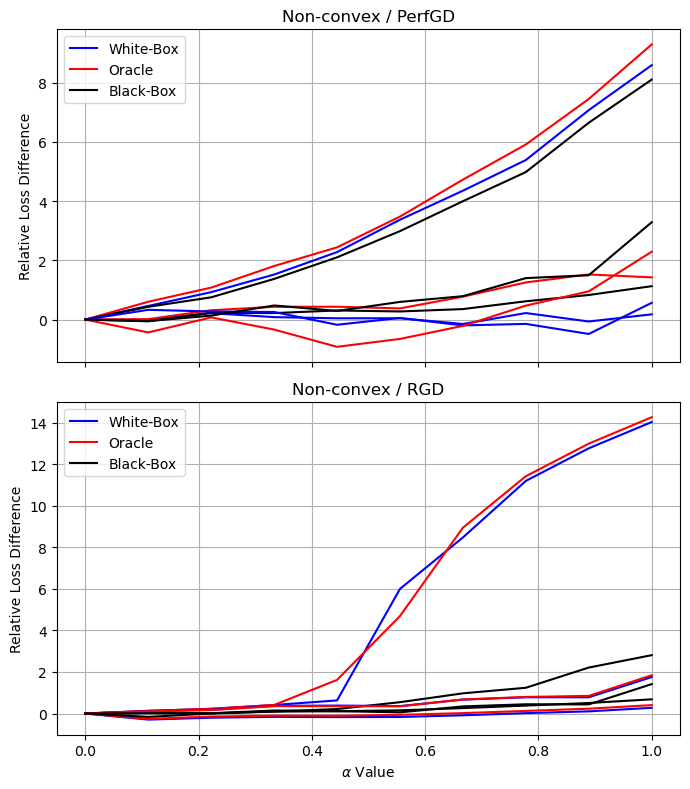

In [47]:
fig, axes = plt.subplots(2, 1, figsize=(7, 8), sharex=True)

# Top subplot: PerfGD
for i, seed in enumerate([1216, 42, 12]):

    white_box_data = pickle.load(open(f'../exports/alpha_sweep/non-convex_PerfGD_white_box_seed{seed}.pkl', 'rb'))
    oracle_data = pickle.load(open(f'../exports/alpha_sweep/non-convex_PerfGD_oracle_seed{seed}.pkl', 'rb'))
    black_box_data = pickle.load(open(f'../exports/alpha_sweep/non-convex_PerfGD_black_box_seed{seed}.pkl', 'rb'))

    white_label = "White-Box" if i == 0 else None
    oracle_label = "Oracle" if i == 0 else None
    black_label = "Black-Box" if i == 0 else None

    axes[0].plot(white_box_data["alpha_vals"], white_box_data["loss_diff"] - white_box_data["loss_diff"][0], label=white_label, color="blue", alpha=1.0)
    axes[0].plot(oracle_data["alpha_vals"], oracle_data["loss_diff"] - oracle_data["loss_diff"][0], label=oracle_label, color="red", alpha=1.0)
    axes[0].plot(black_box_data["alpha_vals"], black_box_data["loss_diff"] - black_box_data["loss_diff"][0], label=black_label, color="black", alpha=1.0)

axes[0].set_ylabel("Relative Loss Difference")
axes[0].set_title("Non-convex / PerfGD")
axes[0].legend()
axes[0].grid(True)

# Bottom subplot: RGD
for i, seed in enumerate([1216, 42, 12]):

    white_box_data = pickle.load(open(f'../exports/alpha_sweep/non-convex_RGD_white_box_seed{seed}.pkl', 'rb'))
    oracle_data = pickle.load(open(f'../exports/alpha_sweep/non-convex_RGD_oracle_seed{seed}.pkl', 'rb'))
    black_box_data = pickle.load(open(f'../exports/alpha_sweep/non-convex_RGD_black_box_seed{seed}.pkl', 'rb'))

    white_label = "White-Box" if i == 0 else None
    oracle_label = "Oracle" if i == 0 else None
    black_label = "Black-Box" if i == 0 else None

    axes[1].plot(white_box_data["alpha_vals"], white_box_data["loss_diff"] - white_box_data["loss_diff"][0], label=white_label, color="blue", alpha=1.0)
    axes[1].plot(oracle_data["alpha_vals"], oracle_data["loss_diff"] - oracle_data["loss_diff"][0], label=oracle_label, color="red", alpha=1)
    axes[1].plot(black_box_data["alpha_vals"], black_box_data["loss_diff"] - black_box_data["loss_diff"][0], label=black_label, color="black", alpha=1)

axes[1].set_ylabel("Relative Loss Difference")
axes[1].set_title("Non-convex / RGD")
axes[1].legend()
axes[1].grid(True)
axes[1].set_xlabel(r"$\alpha$ Value")

plt.tight_layout()
plt.show()
